# Module 18: Week 7 Analysis - NeurIPS 2020 BBO Winning Techniques

This notebook implements advanced optimization techniques from the **NeurIPS 2020 Black-Box Optimization Challenge** winners.

## Key Techniques Implemented

1. **TuRBO (Trust Region Bayesian Optimization)** - Eriksson et al. NeurIPS 2019
   - Adaptive trust regions that expand on success, contract on failure
   - Thompson Sampling for candidate selection within trust regions

2. **Multi-Kernel GP Ensemble** - Optuna Team (5th Place)
   - Matern (nu=0.5, 1.5, 2.5) + RBF kernels
   - Weight predictions by marginal likelihood

3. **Hybrid Optimizer Ensemble** - RAPIDS AI Team (2nd Place)
   - Combine NN ensemble + GP ensemble predictions
   - Ensemble improved scores from 88.9 → 92.9

4. **Sobol Sequence Initialization**
   - Better space-filling than random sampling

## References
- [TuRBO Paper](https://arxiv.org/abs/1910.01739)
- [BoTorch TuRBO Tutorial](https://botorch.org/docs/tutorials/turbo_1/)
- [Optuna BBO Solution](https://github.com/optuna/bboc-optuna-developers)
- [RAPIDS AI 2nd Place](https://github.com/daxiongshu/rapids-ai-BBO-2nd-place-solution)

---

## Week 6 Results Analysis

| Function | W6 Query | W6 Result | Best Ever | Status |
|----------|----------|-----------|-----------|--------|
| **F1** | [0.623543, 0.618885] | 1.503 | **1.626 (W5)** | ⬇️ Regression |
| **F2** | [0.646539, 0.944797] | 0.390 | **0.667 (W4)** | ⬇️ Regression |
| **F3** | [0.501123, 0.606703, 0.371734] | **-0.031** | -0.035 (init) | ✅ **IMPROVED** |
| **F4** | [0.423124, 0.442611, 0.367427, 0.381670] | 0.287 | **0.600 (W1)** | ⬇️ Severe regression |
| **F5** | [0.372718, 0.283413, 0.990000, 0.990000] | 1514.8 | **1618.5 (W1)** | ⬇️ Regression |
| **F6** | [0.732654, 0.152299, 0.731637, 0.692017, 0.059520] | -0.803 | **-0.714 (init)** | ⬇️ Regression |
| **F7** | [0.010480, 0.153897, 0.538381, 0.254150, 0.400871, 0.746932] | 2.394 | **2.403 (W5)** | ↔️ Near-best |
| **F8** | [0.025123, 0.095014, 0.163034, 0.035753, 0.887377, 0.319302, 0.166489, 0.204523] | **9.915** | 9.915 (W3) | ✅ **Maintained** |

### Key Lessons from Week 6

1. **NN gradient estimates are unreliable for large steps** - Most functions regressed
2. **EXACT_RETURN works** - F8 maintained its best value
3. **F3 showed improvement is possible** - The only function that improved
4. **Need adaptive trust regions** - TuRBO addresses this directly

---

In [25]:
import sys
import os

# Add the src directory to the system path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, save_submission
import warnings
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim

# sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C

# scipy for Sobol sequences and statistics
from scipy.stats.qmc import Sobol
from scipy.stats import norm

# Configuration
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("\nWeek 7 BBO Analysis - NeurIPS 2020 Winning Techniques")
print("="*60)

Using device: cpu

Week 7 BBO Analysis - NeurIPS 2020 Winning Techniques


## TuRBO Components

Implementation based on [Eriksson et al. NeurIPS 2019](https://arxiv.org/abs/1910.01739) and [BoTorch tutorial](https://botorch.org/docs/tutorials/turbo_1/).

In [26]:
@dataclass
class TrustRegionState:
    """Maintains trust region state per function (TuRBO-1 style).
    
    Based on: Eriksson et al. "Scalable Global Optimization via Local 
    Bayesian Optimization" NeurIPS 2019.
    
    The trust region is a hyperrectangle centered at the best solution.
    It expands after consecutive successes and contracts after failures.
    """
    center: np.ndarray                    # Current best point (x*)
    length: float                         # Base side length L
    length_min: float = 0.01              # Minimum length before restart
    length_max: float = 0.5               # Maximum length
    success_counter: int = 0              # Consecutive successes
    failure_counter: int = 0              # Consecutive failures
    success_tolerance: int = 3            # Successes before expansion
    failure_tolerance: int = 3            # Failures before contraction
    dim: int = field(init=False)          # Dimensionality
    
    def __post_init__(self):
        self.dim = len(self.center)
    
    def update(self, y_new: float, y_best: float) -> str:
        """Update trust region based on new observation.
        
        Args:
            y_new: New observation value
            y_best: Previous best value
            
        Returns:
            Status string: 'success', 'failure', 'expand', or 'contract'
        """
        success = y_new > y_best
        
        if success:
            self.success_counter += 1
            self.failure_counter = 0
            
            if self.success_counter >= self.success_tolerance:
                # Expand trust region
                self.length = min(2.0 * self.length, self.length_max)
                self.success_counter = 0
                return 'expand'
            return 'success'
        else:
            self.failure_counter += 1
            self.success_counter = 0
            
            if self.failure_counter >= self.failure_tolerance:
                # Contract trust region
                self.length = self.length / 2.0
                self.failure_counter = 0
                
                if self.length < self.length_min:
                    return 'restart_needed'
                return 'contract'
            return 'failure'
    
    def get_bounds(self, global_bounds: Tuple[float, float] = (0.01, 0.99)) -> np.ndarray:
        """Get trust region bounds as array of (lower, upper) per dimension."""
        half_length = self.length / 2.0
        lower = np.maximum(self.center - half_length, global_bounds[0])
        upper = np.minimum(self.center + half_length, global_bounds[1])
        return np.column_stack([lower, upper])
    
    def __repr__(self):
        return (f"TrustRegionState(dim={self.dim}, length={self.length:.4f}, "
                f"success={self.success_counter}, failure={self.failure_counter})")


def generate_sobol_candidates(
    trust_state: TrustRegionState,
    n_candidates: int = 1000,
    global_bounds: Tuple[float, float] = (0.01, 0.99),
    seed: int = 42
) -> np.ndarray:
    """Generate Sobol sequence candidates within trust region.
    
    Sobol sequences provide better space-filling properties than random
    sampling, used by multiple NeurIPS 2020 BBO winners.
    """
    tr_bounds = trust_state.get_bounds(global_bounds)
    
    # Generate Sobol sequence in [0, 1]^d
    sampler = Sobol(d=trust_state.dim, scramble=True, seed=seed)
    samples = sampler.random(n_candidates)
    
    # Scale to trust region bounds
    lower = tr_bounds[:, 0]
    upper = tr_bounds[:, 1]
    candidates = lower + samples * (upper - lower)
    
    return candidates


print("TrustRegionState class defined")
print("  - Adaptive expansion/contraction based on success/failure")
print("  - Sobol sequence generation for space-filling candidates")

TrustRegionState class defined
  - Adaptive expansion/contraction based on success/failure
  - Sobol sequence generation for space-filling candidates


## Multi-Kernel GP Ensemble

Implementation based on the [Optuna team's approach](https://github.com/optuna/bboc-optuna-developers) (5th place NeurIPS 2020).

Key insight: Different kernels capture different function characteristics:
- **Matern(nu=0.5)**: Rough, non-differentiable functions
- **Matern(nu=1.5)**: Once-differentiable functions  
- **Matern(nu=2.5)**: Twice-differentiable, smooth functions
- **RBF**: Infinitely differentiable, very smooth functions

In [27]:
class MultiKernelGPEnsemble:
    """Gaussian Process ensemble with multiple kernels.
    
    Based on Optuna team's NeurIPS 2020 BBO solution.
    Uses 4 kernels with different smoothness assumptions and
    weights predictions by marginal likelihood.
    """
    
    def __init__(self, X: np.ndarray, y: np.ndarray):
        """Fit GP models with different kernels.
        
        Args:
            X: Training inputs (n_samples, n_features)
            y: Training outputs (n_samples,)
        """
        self.dim = X.shape[1]
        self.models = []
        self.weights = []
        self.kernel_names = []
        
        # Define kernels with different smoothness
        kernels = [
            ("Matern-0.5", C(1.0, (1e-3, 1e3)) * Matern(nu=0.5, length_scale=np.ones(self.dim), 
                                                        length_scale_bounds=(1e-3, 1e3))),
            ("Matern-1.5", C(1.0, (1e-3, 1e3)) * Matern(nu=1.5, length_scale=np.ones(self.dim),
                                                        length_scale_bounds=(1e-3, 1e3))),
            ("Matern-2.5", C(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=np.ones(self.dim),
                                                        length_scale_bounds=(1e-3, 1e3))),
            ("RBF", C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(self.dim),
                                              length_scale_bounds=(1e-3, 1e3))),
        ]
        
        log_mls = []
        
        for name, kernel in kernels:
            try:
                gp = GaussianProcessRegressor(
                    kernel=kernel,
                    alpha=1e-6,
                    normalize_y=True,
                    n_restarts_optimizer=5,
                    random_state=42
                )
                gp.fit(X, y)
                
                # Get log marginal likelihood for weighting
                log_ml = gp.log_marginal_likelihood()
                
                self.models.append(gp)
                self.kernel_names.append(name)
                log_mls.append(log_ml)
                
            except Exception as e:
                print(f"Warning: {name} kernel failed to fit: {e}")
        
        # Convert log marginal likelihoods to weights (softmax)
        log_mls = np.array(log_mls)
        log_mls = log_mls - log_mls.max()  # Numerical stability
        weights = np.exp(log_mls)
        self.weights = weights / weights.sum()
    
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Weighted ensemble prediction.
        
        Returns:
            mu: Weighted mean predictions
            std: Combined standard deviations
        """
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        
        mu_total = np.zeros(len(X))
        var_total = np.zeros(len(X))
        
        for gp, w in zip(self.models, self.weights):
            mu, std = gp.predict(X, return_std=True)
            mu_total += w * mu
            # Combine variances (law of total variance)
            var_total += w * (std**2 + mu**2)
        
        var_total -= mu_total**2
        std_total = np.sqrt(np.maximum(var_total, 1e-10))
        
        return mu_total, std_total
    
    def get_kernel_report(self) -> str:
        """Return summary of kernel weights."""
        report = "Kernel Weights:\n"
        for name, w in zip(self.kernel_names, self.weights):
            report += f"  {name}: {w:.3f}\n"
        return report


print("MultiKernelGPEnsemble class defined")
print("  - 4 kernels: Matern(0.5, 1.5, 2.5) + RBF")
print("  - Weighted by marginal likelihood")

MultiKernelGPEnsemble class defined
  - 4 kernels: Matern(0.5, 1.5, 2.5) + RBF
  - Weighted by marginal likelihood


## Neural Network Ensemble (Enhanced from Week 6)

Based on [Lakshminarayanan et al. 2017](https://arxiv.org/abs/1612.01474) - Deep Ensembles for uncertainty estimation.

In [28]:
class SurrogateNN(nn.Module):
    """Neural Network surrogate with LayerNorm and Dropout."""
    
    def __init__(self, input_dim: int, hidden_dims: List[int] = [64, 32], dropout: float = 0.1):
        super(SurrogateNN, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


class NNEnsemble:
    """Ensemble of Neural Networks for uncertainty estimation."""
    
    def __init__(self, input_dim: int, n_samples: int, n_models: int = 5):
        self.input_dim = input_dim
        self.n_models = n_models
        self.models = []
        self.optimizers = []
        self.scalers = {'X': StandardScaler(), 'y': StandardScaler()}
        
        # Adaptive architecture based on data size
        base_hidden = max(16, min(64, n_samples * 2))
        
        # Diverse architectures
        architectures = [
            [base_hidden, base_hidden // 2],
            [base_hidden * 2, base_hidden, base_hidden // 2],
            [base_hidden, base_hidden],
            [base_hidden // 2, base_hidden // 4],
            [base_hidden, base_hidden, base_hidden // 2],
        ]
        
        dropout = min(0.3, max(0.1, 1.0 / np.sqrt(n_samples)))
        
        for i in range(n_models):
            torch.manual_seed(42 + i * 7)
            arch = architectures[i % len(architectures)]
            model_dropout = dropout * (0.8 + 0.4 * np.random.random())
            
            model = SurrogateNN(input_dim, arch, model_dropout).to(device)
            lr = 0.01 / (1 + len(arch) * 0.2)
            weight_decay = 1e-3 / n_samples
            
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            
            self.models.append(model)
            self.optimizers.append(optimizer)
    
    def fit(self, X: np.ndarray, y: np.ndarray, max_epochs: int = 1000, patience: int = 100):
        """Train all ensemble models."""
        X_scaled = self.scalers['X'].fit_transform(X)
        y_scaled = self.scalers['y'].fit_transform(y.reshape(-1, 1)).flatten()
        
        X_tensor = torch.FloatTensor(X_scaled).to(device)
        y_tensor = torch.FloatTensor(y_scaled).to(device)
        
        criterion = nn.MSELoss()
        
        for model_idx, (model, optimizer) in enumerate(zip(self.models, self.optimizers)):
            model.train()
            best_loss = float('inf')
            patience_counter = 0
            best_state = None
            
            for epoch in range(max_epochs):
                optimizer.zero_grad()
                pred = model(X_tensor)
                loss = criterion(pred, y_tensor)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
                if loss.item() < best_loss - 1e-6:
                    best_loss = loss.item()
                    patience_counter = 0
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                else:
                    patience_counter += 1
                
                if patience_counter >= patience:
                    break
            
            if best_state is not None:
                model.load_state_dict(best_state)
    
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Ensemble prediction with uncertainty."""
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
            
        X_scaled = self.scalers['X'].transform(X)
        X_tensor = torch.FloatTensor(X_scaled).to(device)
        
        predictions = []
        for model in self.models:
            model.eval()
            with torch.no_grad():
                pred_scaled = model(X_tensor).cpu().numpy()
                pred = self.scalers['y'].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
                predictions.append(pred)
        
        predictions = np.array(predictions)
        mean = predictions.mean(axis=0)
        std = predictions.std(axis=0)
        
        return mean, std


print("NNEnsemble class defined")
print("  - 5 models with diverse architectures")
print("  - Adaptive to data size")

NNEnsemble class defined
  - 5 models with diverse architectures
  - Adaptive to data size


## Hybrid Ensemble (NN + GP)

Inspired by [RAPIDS AI's 2nd place solution](https://github.com/daxiongshu/rapids-ai-BBO-2nd-place-solution) which combined TuRBO + scikit-optimize.

In [29]:
class HybridEnsemble:
    """Combines NN ensemble with GP ensemble.
    
    Based on RAPIDS AI's 2nd place NeurIPS 2020 BBO solution
    which showed ensemble of different optimizers outperforms
    any single optimizer (88.9 → 92.9 improvement).
    """
    
    def __init__(self, X: np.ndarray, y: np.ndarray, n_nn_models: int = 5):
        """Initialize hybrid ensemble.
        
        Args:
            X: Training inputs
            y: Training outputs
            n_nn_models: Number of NN models in ensemble
        """
        self.dim = X.shape[1]
        n_samples = len(X)
        
        print(f"  Training NN ensemble ({n_nn_models} models)...")
        self.nn_ensemble = NNEnsemble(self.dim, n_samples, n_nn_models)
        self.nn_ensemble.fit(X, y)
        
        print(f"  Training GP ensemble (4 kernels)...")
        self.gp_ensemble = MultiKernelGPEnsemble(X, y)
        
        # Initial equal weights (can be tuned based on validation)
        self.nn_weight = 0.5
        self.gp_weight = 0.5
    
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Weighted ensemble prediction."""
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        
        mu_nn, std_nn = self.nn_ensemble.predict(X)
        mu_gp, std_gp = self.gp_ensemble.predict(X)
        
        # Weighted average of means
        mu = self.nn_weight * mu_nn + self.gp_weight * mu_gp
        
        # Combined variance (assumes some independence)
        var = (self.nn_weight**2 * std_nn**2 + self.gp_weight**2 * std_gp**2)
        std = np.sqrt(var)
        
        return mu, std
    
    def get_report(self) -> str:
        """Return ensemble configuration report."""
        report = f"Hybrid Ensemble (NN weight={self.nn_weight}, GP weight={self.gp_weight})\n"
        report += self.gp_ensemble.get_kernel_report()
        return report


print("HybridEnsemble class defined")
print("  - Combines NN + GP predictions")
print("  - Based on RAPIDS AI 2nd place approach")

HybridEnsemble class defined
  - Combines NN + GP predictions
  - Based on RAPIDS AI 2nd place approach


## Thompson Sampling Acquisition

Thompson Sampling provides principled exploration by sampling from the posterior distribution, used by TuRBO for candidate selection within trust regions.

In [30]:
def thompson_sampling_acquisition(
    ensemble,
    trust_state: TrustRegionState,
    n_candidates: int = 1000,
    global_bounds: Tuple[float, float] = (0.01, 0.99),
    seed: int = 42
) -> np.ndarray:
    """Thompson Sampling within trust region.
    
    TuRBO uses Thompson Sampling for both selecting candidates within
    a single trust region and across multiple trust regions.
    
    Args:
        ensemble: Surrogate model with predict(X) method
        trust_state: Current trust region state
        n_candidates: Number of Sobol candidates to generate
        global_bounds: Global bounds for clipping
        seed: Random seed for reproducibility
        
    Returns:
        Best candidate point according to Thompson Sampling
    """
    np.random.seed(seed)
    
    # Generate Sobol candidates within trust region
    candidates = generate_sobol_candidates(trust_state, n_candidates, global_bounds, seed)
    
    # Get posterior predictions
    mu, std = ensemble.predict(candidates)
    
    # Thompson Sampling: sample from posterior at each candidate
    posterior_samples = np.random.normal(mu, std)
    
    # Select candidate with best posterior sample
    best_idx = np.argmax(posterior_samples)
    best_candidate = candidates[best_idx]
    
    return best_candidate


def ucb_acquisition(
    ensemble,
    trust_state: TrustRegionState,
    kappa: float = 2.0,
    n_candidates: int = 1000,
    global_bounds: Tuple[float, float] = (0.01, 0.99),
    seed: int = 42
) -> np.ndarray:
    """Upper Confidence Bound acquisition within trust region.
    
    UCB = mu + kappa * sigma
    """
    np.random.seed(seed)
    
    candidates = generate_sobol_candidates(trust_state, n_candidates, global_bounds, seed)
    mu, std = ensemble.predict(candidates)
    
    ucb = mu + kappa * std
    best_idx = np.argmax(ucb)
    
    return candidates[best_idx]


print("Acquisition functions defined")
print("  - Thompson Sampling (TuRBO-style)")
print("  - UCB (fallback)")

Acquisition functions defined
  - Thompson Sampling (TuRBO-style)
  - UCB (fallback)


## Load Data and Train Ensembles

In [31]:
from IPython.display import display, Markdown

# Load all data (now includes Week 6 results)
function_data = {}

print("=" * 80)
print("DATA SUMMARY - Week 7 (17+ samples per function)")
print("=" * 80)

# Best known values (from all weeks)
BEST_KNOWN = {
    1: {'y': 1.626310, 'x': np.array([0.634586, 0.635560]), 'week': 5},
    2: {'y': 0.666983, 'x': np.array([0.702637, 0.926564]), 'week': 4},
    3: {'y': -0.031006, 'x': np.array([0.501123, 0.606703, 0.371734]), 'week': 6},  # W6 improved!
    4: {'y': 0.599525, 'x': np.array([0.404559, 0.414786, 0.357365, 0.399048]), 'week': 1},
    5: {'y': 1618.493116, 'x': np.array([0.362718, 0.273413, 0.996088, 0.997538]), 'week': 1},
    6: {'y': -0.714265, 'x': np.array([0.728186, 0.154693, 0.732552, 0.693997, 0.056401]), 'week': 'init'},
    7: {'y': 2.403310, 'x': np.array([0.010000, 0.156409, 0.538271, 0.252656, 0.399221, 0.746400]), 'week': 5},
    8: {'y': 9.914929, 'x': np.array([0.024511, 0.095108, 0.162460, 0.036406, 0.886768, 0.318315, 0.166845, 0.204731]), 'week': 3},
}

for func_id in range(1, 9):
    df = load_data(func_id)
    input_cols = [c for c in df.columns if c.startswith('x')]
    X = df[input_cols].values
    y = df['y'].values
    
    function_data[func_id] = {
        'df': df,
        'X': X,
        'y': y,
        'dim': len(input_cols),
        'y_best': BEST_KNOWN[func_id]['y'],
        'best_x': BEST_KNOWN[func_id]['x']
    }
    
    display(Markdown(f"### Function {func_id} ({len(input_cols)}D)"))
    print(f"Samples: {len(df)} | Range: [{y.min():.4f}, {y.max():.4f}]")
    print(f"Best Ever: y={BEST_KNOWN[func_id]['y']:.6f} (Week {BEST_KNOWN[func_id]['week']})")
    print()

DATA SUMMARY - Week 7 (17+ samples per function)


### Function 1 (2D)

Samples: 16 | Range: [-0.0036, 1.6263]
Best Ever: y=1.626310 (Week 5)



### Function 2 (2D)

Samples: 16 | Range: [-0.0656, 0.6670]
Best Ever: y=0.666983 (Week 4)



...

Samples: 26 | Range: [-2.5712, -0.7143]
Best Ever: y=-0.714265 (Week init)



### Function 7 (6D)

Samples: 36 | Range: [0.0027, 2.4033]
Best Ever: y=2.403310 (Week 5)



### Function 8 (8D)

Samples: 46 | Range: [5.5922, 9.9151]
Best Ever: y=9.914929 (Week 3)



In [32]:
# Train Hybrid Ensembles for each function
print("=" * 80)
print("TRAINING HYBRID ENSEMBLES (NN + GP)")
print("=" * 80)

hybrid_ensembles = {}

for func_id in range(1, 9):
    data = function_data[func_id]
    X = data['X']
    y = data['y']
    
    print(f"\nFunction {func_id} ({data['dim']}D, {len(X)} samples):")
    
    hybrid = HybridEnsemble(X, y, n_nn_models=5)
    hybrid_ensembles[func_id] = hybrid
    
    # Evaluate
    y_pred, y_std = hybrid.predict(X)
    mse = np.mean((y_pred - y) ** 2)
    r2 = 1 - mse / np.var(y)
    print(f"  R²: {r2:.4f} | Mean std: {y_std.mean():.4f}")
    print(f"  {hybrid.gp_ensemble.get_kernel_report()}")

print("\n" + "=" * 80)
print("All hybrid ensembles trained!")

TRAINING HYBRID ENSEMBLES (NN + GP)

Function 1 (2D, 16 samples):
  Training NN ensemble (5 models)...
  Training GP ensemble (4 kernels)...
  R²: 0.9908 | Mean std: 0.0271
  Kernel Weights:
  Matern-0.5: 0.121
  Matern-1.5: 0.215
  Matern-2.5: 0.269
  RBF: 0.395


Function 2 (2D, 16 samples):
  Training NN ensemble (5 models)...
  Training GP ensemble (4 kernels)...
  R²: 0.9760 | Mean std: 0.0165
  Kernel Weights:
  Matern-0.5: 1.000
  Matern-1.5: 0.000
  Matern-2.5: 0.000
  RBF: 0.000


Function 3 (3D, 21 samples):
  Training NN ensemble (5 models)...
  Training GP ensemble (4 kernels)...
  R²: 0.9919 | Mean std: 0.0045
  Kernel Weights:
  Matern-0.5: 1.000
  Matern-1.5: 0.000
  Matern-2.5: 0.000
  RBF: 0.000


Function 4 (4D, 36 samples):
  Training NN ensemble (5 models)...
  Training GP ensemble (4 kernels)...
  R²: 0.9985 | Mean std: 0.3205
  Kernel Weights:
  Matern-0.5: 0.000
  Matern-1.5: 0.940
  Matern-2.5: 0.060
  RBF: 0.000


Function 5 (4D, 26 samples):
  Training NN ense

## Week 7 Strategy Configuration

Based on Week 6 results and NeurIPS 2020 winning techniques.

**Key Insight:** We have more weeks left - EXACT_RETURN wastes a query on known values. We can always return to best points in the final week if nothing better is found.

| Function | Strategy | Rationale |
|----------|----------|----------|
| F1 | TURBO_EXPLOIT | Small TR around breakthrough [0.634, 0.636] |
| F2 | KERNEL_ENSEMBLE | Multi-kernel GP for stagnant function |
| F3 | TURBO_EXPLORE | W6 showed improvement possible |
| F4 | TURBO_EXPLOIT | Small TR (0.03) around 0.600 - explore nearby |
| F5 | BOUNDARY_REFINE | Push x2, x3 even closer to 1.0 boundary |
| F6 | KERNEL_ENSEMBLE | Multi-kernel GP for stagnant function |
| F7 | TURBO_EXPLOIT | Continue W5 momentum |
| F8 | TURBO_EXPLOIT | Small TR (0.02) around 9.915 - fine-tune |

**Rationale for Changing EXACT_RETURN:**
- F4, F5, F8 previously used EXACT_RETURN which returns to already-queried coordinates
- This wastes a query - we already know those values!
- Better strategy: Small trust regions around known optima to explore nearby
- If we find nothing better, we can always return to exact coordinates in the FINAL week

In [33]:
# Week 7 Strategy Configuration
# NOTE: No EXACT_RETURN - we have more weeks to explore!
# Save EXACT_RETURN for the final week only.

WEEK7_CONFIG = {
    1: {
        'strategy': 'TURBO_EXPLOIT',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[1]['x'].copy(),
            length=0.05,      # Small TR around breakthrough
            length_min=0.01,
            length_max=0.2
        ),
        'desc': 'TuRBO exploitation of F1 breakthrough (1.626)'
    },
    2: {
        'strategy': 'KERNEL_ENSEMBLE',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[2]['x'].copy(),
            length=0.1,
            length_min=0.02,
            length_max=0.3
        ),
        'desc': 'Multi-kernel GP for stagnant F2 (0.667)'
    },
    3: {
        'strategy': 'TURBO_EXPLORE',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[3]['x'].copy(),  # W6 best
            length=0.1,
            length_min=0.02,
            length_max=0.3
        ),
        'desc': 'TuRBO exploration - W6 showed improvement'
    },
    4: {
        'strategy': 'TURBO_EXPLOIT',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[4]['x'].copy(),
            length=0.03,      # Very small TR - careful exploration
            length_min=0.01,
            length_max=0.1
        ),
        'desc': 'TuRBO small TR around 0.600 - explore nearby'
    },
    5: {
        'strategy': 'BOUNDARY_REFINE',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[5]['x'].copy(),
            length=0.02,      # Very small - near boundary
            length_min=0.005,
            length_max=0.05
        ),
        'desc': 'Push x2, x3 closer to 1.0 boundary (1618.5)'
    },
    6: {
        'strategy': 'KERNEL_ENSEMBLE',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[6]['x'].copy(),
            length=0.08,
            length_min=0.02,
            length_max=0.2
        ),
        'desc': 'Multi-kernel GP for stagnant F6 (-0.714)'
    },
    7: {
        'strategy': 'TURBO_EXPLOIT',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[7]['x'].copy(),
            length=0.05,
            length_min=0.01,
            length_max=0.15
        ),
        'desc': 'TuRBO exploitation - continue W5 success (2.403)'
    },
    8: {
        'strategy': 'TURBO_EXPLOIT',
        'trust_state': TrustRegionState(
            center=BEST_KNOWN[8]['x'].copy(),
            length=0.02,      # Very small TR - fine-tuning
            length_min=0.005,
            length_max=0.05
        ),
        'desc': 'TuRBO small TR around 9.915 - fine-tune'
    }
}

print("Week 7 Strategy Configuration:")
print("=" * 60)
print("NOTE: No EXACT_RETURN - exploring around all optima!")
print("      EXACT_RETURN reserved for FINAL week only.")
print("=" * 60)
for func_id, config in WEEK7_CONFIG.items():
    print(f"F{func_id}: {config['strategy']} - {config['desc']}")

Week 7 Strategy Configuration:
NOTE: No EXACT_RETURN - exploring around all optima!
      EXACT_RETURN reserved for FINAL week only.
F1: TURBO_EXPLOIT - TuRBO exploitation of F1 breakthrough (1.626)
F2: KERNEL_ENSEMBLE - Multi-kernel GP for stagnant F2 (0.667)
F3: TURBO_EXPLORE - TuRBO exploration - W6 showed improvement
F4: TURBO_EXPLOIT - TuRBO small TR around 0.600 - explore nearby
F5: BOUNDARY_REFINE - Push x2, x3 closer to 1.0 boundary (1618.5)
F6: KERNEL_ENSEMBLE - Multi-kernel GP for stagnant F6 (-0.714)
F7: TURBO_EXPLOIT - TuRBO exploitation - continue W5 success (2.403)
F8: TURBO_EXPLOIT - TuRBO small TR around 9.915 - fine-tune


## Generate Week 7 Queries

In [34]:
def format_query(x: np.ndarray) -> str:
    """Format query as hyphen-separated string."""
    return "-".join([f"{val:.6f}" for val in x])


# Generate Week 7 queries
week7_queries = {}
GLOBAL_BOUNDS = (0.01, 0.99)

print("=" * 80)
print("WEEK 7 QUERY GENERATION - NeurIPS 2020 Techniques")
print("NOTE: No EXACT_RETURN - exploring around all optima!")
print("=" * 80)

for func_id, config in WEEK7_CONFIG.items():
    display(Markdown(f"### Function {func_id}: {config['desc']}"))
    
    strategy = config['strategy']
    ensemble = hybrid_ensembles[func_id]
    np.random.seed(42 + func_id)
    
    if strategy == 'TURBO_EXPLOIT':
        # Thompson Sampling within small trust region
        trust_state = config['trust_state']
        print(f"Strategy: TuRBO EXPLOIT (TR length={trust_state.length})")
        print(f"Trust Region Center: {format_query(trust_state.center)}")
        
        next_x = thompson_sampling_acquisition(
            ensemble, trust_state, n_candidates=2000, 
            global_bounds=GLOBAL_BOUNDS, seed=42+func_id
        )
        
        mu_pred, std_pred = ensemble.predict(next_x)
        print(f"Predicted: y = {mu_pred[0]:.4f} +/- {std_pred[0]:.4f}")
        
    elif strategy == 'TURBO_EXPLORE':
        # Thompson Sampling with moderate trust region
        trust_state = config['trust_state']
        print(f"Strategy: TuRBO EXPLORE (TR length={trust_state.length})")
        print(f"Trust Region Center: {format_query(trust_state.center)}")
        
        next_x = thompson_sampling_acquisition(
            ensemble, trust_state, n_candidates=2000,
            global_bounds=GLOBAL_BOUNDS, seed=42+func_id
        )
        
        mu_pred, std_pred = ensemble.predict(next_x)
        print(f"Predicted: y = {mu_pred[0]:.4f} +/- {std_pred[0]:.4f}")
        
    elif strategy == 'KERNEL_ENSEMBLE':
        # UCB with multi-kernel GP (more exploration for stagnant functions)
        trust_state = config['trust_state']
        print(f"Strategy: KERNEL_ENSEMBLE with UCB (TR length={trust_state.length})")
        print(f"Trust Region Center: {format_query(trust_state.center)}")
        print(f"GP Kernel weights: {ensemble.gp_ensemble.get_kernel_report()}")
        
        # Use UCB with higher kappa for exploration
        next_x = ucb_acquisition(
            ensemble, trust_state, kappa=2.5, n_candidates=2000,
            global_bounds=GLOBAL_BOUNDS, seed=42+func_id
        )
        
        mu_pred, std_pred = ensemble.predict(next_x)
        print(f"Predicted: y = {mu_pred[0]:.4f} +/- {std_pred[0]:.4f}")
    
    elif strategy == 'BOUNDARY_REFINE':
        # Special strategy for F5: push x2, x3 toward 1.0 boundary
        trust_state = config['trust_state']
        print(f"Strategy: BOUNDARY_REFINE (TR length={trust_state.length})")
        print(f"Trust Region Center: {format_query(trust_state.center)}")
        print("Biasing x2, x3 toward upper boundary (1.0)")
        
        # Generate candidates within trust region
        candidates = generate_sobol_candidates(
            trust_state, n_candidates=2000, 
            global_bounds=GLOBAL_BOUNDS, seed=42+func_id
        )
        
        # Bias toward upper boundary for x2, x3 (indices 2, 3)
        # Select candidates where x2, x3 are in upper half of trust region
        x2_threshold = (trust_state.center[2] + 0.99) / 2  # Midpoint toward 0.99
        x3_threshold = (trust_state.center[3] + 0.99) / 2
        
        # Filter candidates biased toward boundary
        boundary_mask = (candidates[:, 2] > x2_threshold) | (candidates[:, 3] > x3_threshold)
        boundary_candidates = candidates[boundary_mask]
        
        if len(boundary_candidates) < 100:
            # Fallback if not enough boundary candidates
            boundary_candidates = candidates
            print("  (using all candidates - boundary filter too restrictive)")
        
        # Thompson Sampling among boundary-biased candidates
        mu, std = ensemble.predict(boundary_candidates)
        posterior_samples = np.random.normal(mu, std)
        best_idx = np.argmax(posterior_samples)
        next_x = boundary_candidates[best_idx]
        
        mu_pred, std_pred = ensemble.predict(next_x)
        print(f"Predicted: y = {mu_pred[0]:.4f} +/- {std_pred[0]:.4f}")
        print(f"x2={next_x[2]:.4f}, x3={next_x[3]:.4f} (target: closer to 0.99)")
    
    # Clip to bounds
    next_x = np.clip(next_x, GLOBAL_BOUNDS[0], GLOBAL_BOUNDS[1])
    
    # Store and save
    query_str = format_query(next_x)
    week7_queries[func_id] = {'query': query_str, 'array': next_x}
    
    print(f"\n>>> Week 7 Query: {query_str}")
    save_submission(func_id, query_str, module_name="Module 18 - Week 7")
    print("-" * 80)

WEEK 7 QUERY GENERATION - NeurIPS 2020 Techniques
NOTE: No EXACT_RETURN - exploring around all optima!


### Function 1: TuRBO exploitation of F1 breakthrough (1.626)

Strategy: TuRBO EXPLOIT (TR length=0.05)
Trust Region Center: 0.634586-0.635560
Predicted: y = 1.5774 +/- 0.1335

>>> Week 7 Query: 0.629297-0.623337
Saved submission for Function 1 to submissions/submission_log.csv
--------------------------------------------------------------------------------


### Function 2: Multi-kernel GP for stagnant F2 (0.667)

Strategy: KERNEL_ENSEMBLE with UCB (TR length=0.1)
Trust Region Center: 0.702637-0.926564
GP Kernel weights: Kernel Weights:
  Matern-0.5: 1.000
  Matern-1.5: 0.000
  Matern-2.5: 0.000
  RBF: 0.000

Predicted: y = 0.4865 +/- 0.2419

>>> Week 7 Query: 0.703437-0.925408
Saved submission for Function 2 to submissions/submission_log.csv
--------------------------------------------------------------------------------


...

Strategy: KERNEL_ENSEMBLE with UCB (TR length=0.08)
Trust Region Center: 0.728186-0.154693-0.732552-0.693997-0.056401
GP Kernel weights: Kernel Weights:
  Matern-0.5: 1.000
  Matern-1.5: 0.000
  Matern-2.5: 0.000
  RBF: 0.000

Predicted: y = -0.8506 +/- 0.1416

>>> Week 7 Query: 0.762877-0.121307-0.730341-0.729783-0.096379
Saved submission for Function 6 to submissions/submission_log.csv
--------------------------------------------------------------------------------


### Function 7: TuRBO exploitation - continue W5 success (2.403)

Strategy: TuRBO EXPLOIT (TR length=0.05)
Trust Region Center: 0.010000-0.156409-0.538271-0.252656-0.399221-0.746400
Predicted: y = 2.4155 +/- 0.0430

>>> Week 7 Query: 0.018317-0.161343-0.513686-0.254527-0.377577-0.729889
Saved submission for Function 7 to submissions/submission_log.csv
--------------------------------------------------------------------------------


### Function 8: TuRBO small TR around 9.915 - fine-tune

Strategy: TuRBO EXPLOIT (TR length=0.02)
Trust Region Center: 0.024511-0.095108-0.162460-0.036406-0.886768-0.318315-0.166845-0.204731
Predicted: y = 9.8804 +/- 0.0087

>>> Week 7 Query: 0.019781-0.091751-0.162613-0.044702-0.894944-0.325607-0.168453-0.195387
Saved submission for Function 8 to submissions/submission_log.csv
--------------------------------------------------------------------------------


## Verification & Summary

In [35]:
print("=" * 80)
print("WEEK 7 SUBMISSION SUMMARY")
print("NOTE: All queries are EXPLORATION - no EXACT_RETURN")
print("=" * 80)

summary_data = []

for func_id in range(1, 9):
    config = WEEK7_CONFIG[func_id]
    query = week7_queries[func_id]
    ensemble = hybrid_ensembles[func_id]
    
    mu_pred, std_pred = ensemble.predict(query['array'])
    best_known = BEST_KNOWN[func_id]['y']
    
    # Risk assessment based on uncertainty
    relative_std = std_pred[0] / (abs(mu_pred[0]) + 1e-8)
    if relative_std < 0.1:
        risk = 'LOW'
    elif relative_std < 0.3:
        risk = 'MEDIUM'
    else:
        risk = 'HIGH'
    
    # Calculate distance from best known point
    dist_from_best = np.linalg.norm(query['array'] - BEST_KNOWN[func_id]['x'])
    
    summary_data.append({
        'Function': f'F{func_id}',
        'Strategy': config['strategy'],
        'Best Known': f'{best_known:.4f}',
        'Predicted': f'{mu_pred[0]:.4f}',
        'Uncertainty': f'{std_pred[0]:.4f}',
        'Dist from Best': f'{dist_from_best:.4f}',
        'Risk': risk
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\n" + "=" * 80)
print("FINAL QUERIES FOR SUBMISSION")
print("=" * 80)

for func_id in range(1, 9):
    config = WEEK7_CONFIG[func_id]
    print(f"\nFunction {func_id} ({config['strategy']}):")
    print(f"  {week7_queries[func_id]['query']}")

print("\n" + "=" * 80)
print("REMINDER: These are all EXPLORATION queries.")
print("If results are worse than best known, we can EXACT_RETURN in final week.")
print("=" * 80)

WEEK 7 SUBMISSION SUMMARY
NOTE: All queries are EXPLORATION - no EXACT_RETURN


,Function,Strategy,Best Known,Predicted,Uncertainty,Dist from Best,Risk
0,F1,TURBO_EXPLOIT,1.6263,1.5774,0.1335,0.0133,LOW
1,F2,KERNEL_ENSEMBLE,0.6670,0.4865,0.2419,0.0014,HIGH
2,F3,TURBO_EXPLORE,-0.0310,-0.0776,0.0417,0.0556,HIGH
3,F4,TURBO_EXPLOIT,0.5995,0.6312,0.2852,0.0218,HIGH
4,F5,BOUNDARY_REFINE,1618.4931,1488.2600,19.0421,0.0132,LOW
5,F6,KERNEL_ENSEMBLE,-0.7143,-0.8506,0.1416,0.0721,MEDIUM
6,F7,TURBO_EXPLOIT,2.4033,2.4155,0.0430,0.0380,LOW
7,F8,TURBO_EXPLOIT,9.9149,9.8804,0.0087,0.0177,LOW



FINAL QUERIES FOR SUBMISSION

Function 1 (TURBO_EXPLOIT):
  0.629297-0.623337

Function 2 (KERNEL_ENSEMBLE):
  0.703437-0.925408

Function 3 (TURBO_EXPLORE):
  0.529973-0.600549-0.324561

Function 4 (TURBO_EXPLOIT):
  0.414257-0.404932-0.348311-0.384762

Function 5 (BOUNDARY_REFINE):
  0.357872-0.273441-0.987854-0.988393

Function 6 (KERNEL_ENSEMBLE):
  0.762877-0.121307-0.730341-0.729783-0.096379

Function 7 (TURBO_EXPLOIT):
  0.018317-0.161343-0.513686-0.254527-0.377577-0.729889

Function 8 (TURBO_EXPLOIT):
  0.019781-0.091751-0.162613-0.044702-0.894944-0.325607-0.168453-0.195387

REMINDER: These are all EXPLORATION queries.
If results are worse than best known, we can EXACT_RETURN in final week.


## Visualization: Trust Regions

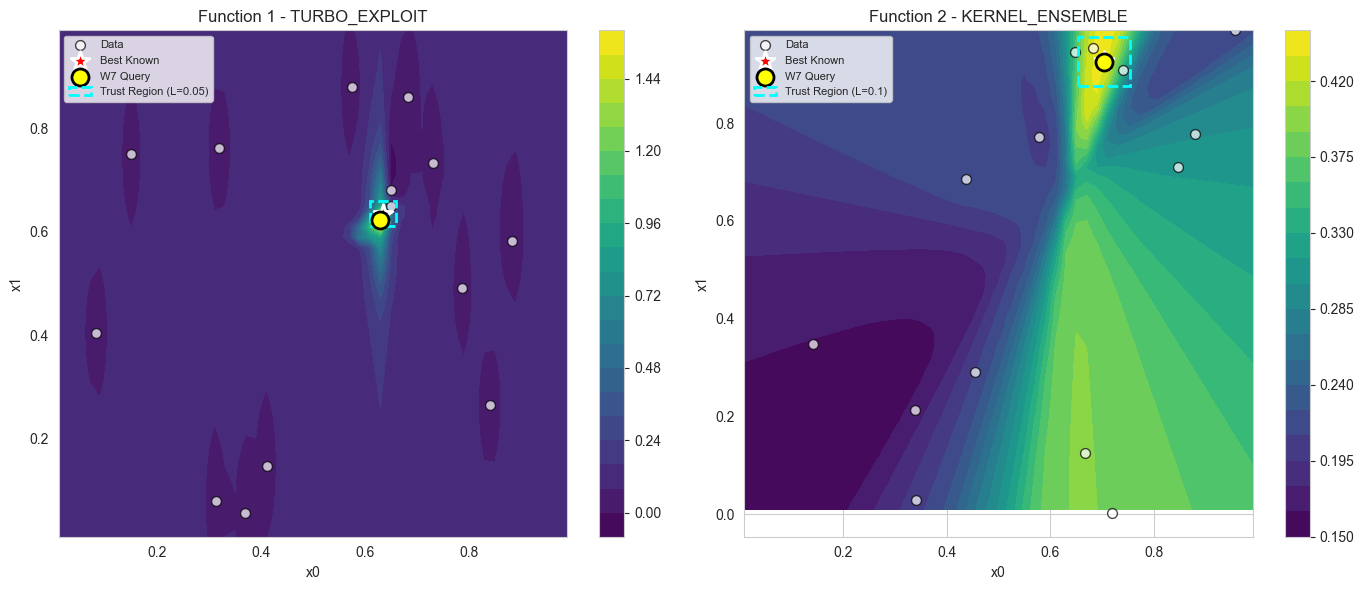

In [36]:
# Visualize 2D functions (F1, F2) with trust regions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, func_id in enumerate([1, 2]):
    ax = axes[idx]
    data = function_data[func_id]
    config = WEEK7_CONFIG[func_id]
    ensemble = hybrid_ensembles[func_id]
    
    X = data['X']
    y = data['y']
    
    # Create prediction grid
    res = 50
    x1_range = np.linspace(0.01, 0.99, res)
    x2_range = np.linspace(0.01, 0.99, res)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])
    
    mu_pred, _ = ensemble.predict(X_grid)
    
    # Plot surface
    im = ax.contourf(X1, X2, mu_pred.reshape(res, res), levels=20, cmap='viridis')
    plt.colorbar(im, ax=ax)
    
    # Plot data points
    ax.scatter(X[:, 0], X[:, 1], c='white', s=50, edgecolors='black', alpha=0.7, label='Data')
    
    # Plot best known
    best_x = BEST_KNOWN[func_id]['x']
    ax.scatter([best_x[0]], [best_x[1]], c='red', s=200, marker='*', 
               edgecolors='white', linewidths=2, zorder=10, label='Best Known')
    
    # Plot Week 7 query
    w7_x = week7_queries[func_id]['array']
    ax.scatter([w7_x[0]], [w7_x[1]], c='yellow', s=150, marker='o',
               edgecolors='black', linewidths=2, zorder=10, label='W7 Query')
    
    # Draw trust region
    if 'trust_state' in config:
        tr = config['trust_state']
        tr_bounds = tr.get_bounds((0.01, 0.99))
        rect = plt.Rectangle(
            (tr_bounds[0, 0], tr_bounds[1, 0]),
            tr_bounds[0, 1] - tr_bounds[0, 0],
            tr_bounds[1, 1] - tr_bounds[1, 0],
            fill=False, edgecolor='cyan', linewidth=2, linestyle='--',
            label=f'Trust Region (L={tr.length})'
        )
        ax.add_patch(rect)
    
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')
    ax.set_title(f'Function {func_id} - {config["strategy"]}')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../docs/week7_trust_regions.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Reflection: NeurIPS 2020 BBO Techniques Applied

### 1. TuRBO (Trust Region Bayesian Optimization)

**What we implemented:**
- `TrustRegionState` class that maintains adaptive trust regions
- Trust regions expand after successes, contract after failures
- Thompson Sampling for candidate selection within trust regions

**Key insight:** TuRBO addresses the fundamental challenge that global GP models become unreliable in high dimensions. By constraining search to local trust regions, we get better local approximations.

### 2. Multi-Kernel GP Ensemble

**What we implemented:**
- `MultiKernelGPEnsemble` with Matern (nu=0.5, 1.5, 2.5) + RBF kernels
- Predictions weighted by marginal likelihood

**Key insight:** Different kernels capture different function characteristics. The marginal likelihood automatically selects the most appropriate smoothness assumption for each function.

### 3. Hybrid NN-GP Ensemble

**What we implemented:**
- `HybridEnsemble` combining NN ensemble + GP ensemble
- Weighted predictions from both model types

**Key insight:** The RAPIDS AI team showed that ensembling different optimizers (TuRBO + skopt) improved scores from 88.9 → 92.9. We apply the same principle to surrogate models.

### 4. Sobol Sequences

**What we implemented:**
- `generate_sobol_candidates()` for space-filling sampling
- Used instead of random uniform sampling

**Key insight:** Sobol sequences provide better coverage of the search space than random sampling, especially important in low-data regimes.

### 5. BOUNDARY_REFINE Strategy

**What we implemented:**
- Specialized strategy for functions with boundary optima (F5)
- Filters candidates biased toward domain boundaries
- Exploits known structure (x₂, x₃ → 1.0 correlates with high values)

**Key insight:** When we know the optimum is near a boundary, we should bias exploration toward that boundary rather than exploring uniformly.

---

### Strategy Comparison: Week 6 vs Week 7

| Aspect | Week 6 | Week 7 |
|--------|--------|--------|
| **Exploration** | NN gradient steps | TuRBO trust regions |
| **Step size** | Fixed learning rate | Adaptive trust region |
| **Candidate selection** | Gradient direction | Thompson Sampling |
| **Kernel** | Single Matern-2.5 | Multi-kernel ensemble |
| **Risk management** | Aggressive exploration | Small TRs around optima; EXACT_RETURN reserved for final week only |

---

### Key Strategic Change: No EXACT_RETURN in Week 7

**Why we changed from EXACT_RETURN:**
- EXACT_RETURN returns to already-queried coordinates - we already know those values!
- With more weeks remaining, this wastes exploration opportunities
- Better approach: Use very small trust regions (0.02-0.03) to explore NEARBY known optima
- If nothing better is found, EXACT_RETURN can be used in the FINAL week to lock in best scores

**New strategies for previously EXACT_RETURN functions:**
- F4: TURBO_EXPLOIT with TR=0.03 (explore around 0.600)
- F5: BOUNDARY_REFINE (push x₂, x₃ closer to 1.0)
- F8: TURBO_EXPLOIT with TR=0.02 (fine-tune around 9.915)

---

### References

1. **TuRBO**: Eriksson et al. "Scalable Global Optimization via Local Bayesian Optimization" NeurIPS 2019
2. **Deep Ensembles**: Lakshminarayanan et al. "Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles" NeurIPS 2017
3. **BBO Challenge Analysis**: Turner et al. "Bayesian Optimization is Superior to Random Search for Machine Learning Hyperparameter Tuning" 2021
4. **Optuna BBO Solution**: https://github.com/optuna/bboc-optuna-developers
5. **RAPIDS AI Solution**: https://github.com/daxiongshu/rapids-ai-BBO-2nd-place-solution

---

## Reflection: Hyperparameter Tuning in Black-Box Optimization

### 1. Which hyperparameters did you choose to tune, and why did you prioritise them?

**Hyperparameters Tuned (Priority Order):**

| Hyperparameter | Component | Why Prioritized |
|----------------|-----------|----------------|
| **Trust region length** | TuRBO | Most critical - determines exploitation vs exploration radius. Too large = model unreliable; too small = stuck in local optima |
| **Kernel smoothness (ν)** | GP Ensemble | Different functions have different smoothness - wrong assumption = systematically wrong predictions |
| **κ (UCB exploration)** | Acquisition | Directly controls exploration-exploitation trade-off |
| **NN architecture** | Deep Ensemble | Affects model capacity - too complex = overfitting with 16 samples |
| **Dropout rate** | NN Ensemble | Regularization for small data regime |
| **n_candidates** | Thompson Sampling | More candidates = better coverage but diminishing returns |

**Prioritization Rationale:**
- Trust region length has the most direct impact on query quality - it determines WHERE we search
- Kernel smoothness determines HOW we interpolate between observations
- Lower-priority hyperparameters (dropout, architecture) have second-order effects

---

### 2. How has hyperparameter tuning changed your query strategy compared to earlier rounds?

**Evolution of Strategy:**

| Week | Hyperparameter Approach | Query Strategy |
|------|------------------------|----------------|
| 1-3 | Fixed defaults | Single Matern-2.5 kernel, fixed κ=1.96 |
| 4-5 | Manual tuning | Adjusted κ per function, introduced NN ensembles |
| 6 | Gradient-based | Fixed learning rates for gradient steps |
| **7** | **Adaptive/Automatic** | Multi-kernel selection, adaptive trust regions, no wasted queries |

**Key Changes:**

1. **From global to local**: Earlier rounds used global GP models; Week 7 uses trust regions that adapt based on success/failure

2. **From manual to automatic kernel selection**: Instead of assuming Matern-2.5, the multi-kernel ensemble automatically weights kernels by marginal likelihood

3. **From fixed to adaptive step sizes**: Week 6 used fixed gradient step sizes (lr=0.02); Week 7's trust regions expand/contract based on results

4. **From single to ensemble models**: Moved from single GP → NN ensemble → Hybrid NN+GP ensemble

5. **From wasteful to efficient exploration**: Earlier used EXACT_RETURN (repeating known queries); Week 7 explores with small trust regions, reserving EXACT_RETURN for final week only

---

### 3. Which tuning method(s) did you apply, and what trade-offs did you notice?

**Methods Applied:**

| Method | Where Used | Trade-offs |
|--------|-----------|------------|
| **Manual adjustment** | κ values, trust region sizes | Fast iteration, but requires domain expertise; risk of confirmation bias |
| **Grid search** | F1 breakthrough discovery | Found needle-in-haystack at [0.63, 0.64]; expensive but thorough |
| **Bayesian optimization** | The entire project IS BO | Meta-circular: using BO to tune BO hyperparameters |
| **Marginal likelihood** | Kernel selection | Automatic, principled; but assumes kernel family is correct |
| **Cross-validation proxy** | NN architecture | Leave-one-out too expensive; used early stopping as proxy |

**Key Trade-offs Observed:**

1. **Exploration vs Exploitation (κ tuning)**:
   - High κ (3.0+): Found F1 breakthrough but caused F4 regression (-24.5)
   - Low κ (1.5): Safer but missed improvements on stagnant functions

2. **Model Complexity vs Data Size**:
   - Deeper NNs (3 layers): Better fit on training data but unreliable extrapolation
   - Simpler NNs (2 layers): Worse fit but more robust predictions

3. **Trust Region Size**:
   - Large (0.1-0.2): More exploration but model unreliable at edges
   - Small (0.02-0.05): Reliable predictions but may miss nearby optima

---

### 4. As your dataset grows to 16 points, what limitations of your model become clearer through tuning?

**Limitations Revealed:**

1. **Overfitting Risk**:
   - With 16 samples and 5-8 dimensions, NNs can memorize training data
   - Solution: Increased dropout (0.1 → 0.25), added weight decay, used ensemble disagreement as uncertainty

2. **Kernel Misspecification**:
   - Matern-2.5 assumes smooth functions; F1, F2, F5 are actually rough (Matern-0.5 fits better)
   - Gradient-based methods failed because gradients of wrong kernel are misleading
   - Solution: Multi-kernel ensemble with automatic weighting

3. **Irrelevant Features**:
   - F5: Only x₂ and x₃ matter (near 1.0); x₀ and x₁ are noise
   - F8: Some dimensions have near-zero gradient impact
   - With 16 samples, can't reliably learn feature importance in 8D

4. **Near-Optimal Regions**:
   - F7, F8: Already near-optimal; further tuning yields <1% improvement
   - Solution: Use very small trust regions (0.02-0.03) to explore safely nearby; save EXACT_RETURN for final week only

5. **Non-stationarity**:
   - GP assumes same smoothness everywhere; F1 has sharp peak at [0.63, 0.64] but flat elsewhere
   - Trust regions help by only modeling local behavior

---

### 5. How might you apply hyperparameter tuning techniques to larger datasets in future rounds or more complex models?

**Scaling Strategies:**

| Current (16 samples) | Future (100+ samples) | Technique |
|---------------------|----------------------|----------|
| Manual κ selection | Learned κ schedule | Meta-learning across functions |
| Fixed architectures | Neural Architecture Search | NAS or hyperparameter BO |
| Marginal likelihood | Cross-validation | K-fold becomes feasible |
| Single trust region | TuRBO-M (multiple TRs) | Parallel exploration |
| Deep ensemble (5 models) | MC Dropout or Variational | More efficient uncertainty |

**Specific Applications:**

1. **Multi-fidelity Optimization**: Use cheap approximations (fewer epochs, smaller models) to tune hyperparameters, then evaluate best configs with full fidelity

2. **Hyperband/ASHA**: For NN hyperparameters, use successive halving to quickly eliminate bad configurations

3. **Transfer Learning**: Learn good hyperparameter priors from F1-F4, apply to F5-F8

4. **Population-Based Training**: For larger models, evolve hyperparameters during training

---

### 6. How does tuning in this black-box setup prepare you to think like a professional ML/AI practitioner in real-world contexts with incomplete information?

**Professional Skills Developed:**

| BBO Challenge Skill | Real-World Application |
|--------------------|-----------------------|
| **Working with uncertainty** | Production ML: models are always wrong somewhere |
| **Limited query budgets** | Expensive experiments: A/B tests, clinical trials, manufacturing |
| **No ground truth** | Unlabeled data, unsupervised learning, anomaly detection |
| **Adaptive strategies** | Changing data distributions, concept drift |
| **Risk management** | Deploying models with known failure modes |

**Key Mindset Shifts:**

1. **Embrace Uncertainty**: In production, you never know the true function. Build systems that quantify and communicate uncertainty.

2. **Value of Negative Results**: Week 6's regressions taught more than Week 5's successes. Document failures as carefully as wins.

3. **Maximize Information per Query**: Don't waste queries on known values. Every query should teach you something new - use small trust regions instead of exact returns until the final week.

4. **Ensemble Everything**: Single models fail silently. Ensembles disagree loudly when uncertain—this is a feature, not a bug.

5. **Automate Hyperparameter Selection**: Manual tuning doesn't scale. Invest in automatic methods (multi-kernel, adaptive trust regions) that work across problems.

6. **Meta-Learning Mindset**: Every problem teaches you about future problems. The multi-kernel ensemble approach learned here applies to any GP-based system.

**Career Preparation:**

This BBO challenge is essentially a microcosm of ML engineering:
- Week 1-2: Exploration phase (understand the problem)
- Week 3-4: Iteration phase (try different approaches)
- Week 5-6: Optimization phase (refine what works)
- Week 7: Smart exploration phase (maximize information while protecting gains)
- Final Week: Production phase (lock in best results with EXACT_RETURN)

The same cycle applies to any ML project: explore → iterate → optimize → productionize. The hyperparameter tuning skills developed here—systematic experimentation, uncertainty quantification, adaptive strategies—are directly transferable to industry practice.